In [1]:
from pathlib import Path
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, ccf

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import tensorflow as tf
import xgboost as xgb
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, TimeDistributed, Flatten, Dropout, RepeatVector

%matplotlib inline

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data")

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        print(path)

I0000 00:00:1780939275.553152   56515 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780939275.605093   56515 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780939277.738980   56515 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


../data/weather_features.csv
../data/df_final.csv
../data/energy_dataset.csv


In [2]:
df_final = pd.read_csv(
    DATA_DIR / "df_final.csv",
    index_col="time",
    parse_dates=["time"]
)

In [3]:
################
# Feature Selection
################

In [4]:
# Feature Selection
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i-history_size, i, step)
        data.append(dataset[indices])

        if single_step:
            labels.append(target[i + target_size])
        else:
            labels.append(target[i : i + target_size])

    return np.array(data), np.array(labels)

In [5]:
train_end_idx = 27048
cv_end_idx = 31056
test_end_idx = 35064

In [6]:
X = df_final[df_final.columns.drop('price actual')].values
y = df_final['price actual'].values


y = y.reshape(-1, 1)

In [7]:
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

In [8]:
scaler_X.fit(X[:train_end_idx])
scaler_y.fit(y[:train_end_idx])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [9]:
X_norm = scaler_X.transform(X)
y_norm = scaler_y.transform(y)

In [10]:
pca = PCA()
X_pca = pca.fit(X_norm[:train_end_idx])

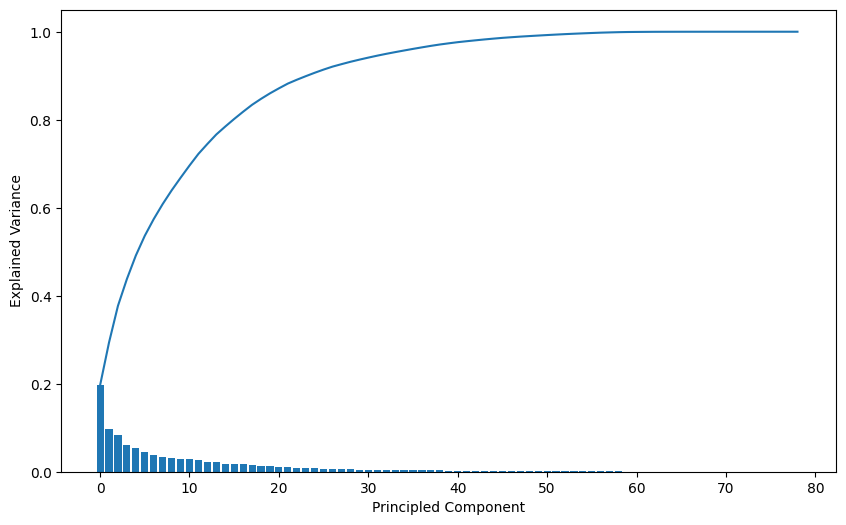

In [11]:
num_components = len(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.bar(np.arange(num_components), pca.explained_variance_ratio_)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Principled Component')
plt.ylabel('Explained Variance')
plt.show()

In [12]:
pca = PCA(n_components=0.80)
pca.fit(X_norm[:train_end_idx])
X_pca = pca.transform(X_norm)

In [13]:
X_pca.shape

(35064, 16)

In [14]:
dataset_norm = np.concatenate((X_pca, y_norm), axis=1)

past_history = 24
future_target = 0

In [15]:
X_train, y_train = multivariate_data(dataset_norm, dataset_norm[:,-1],
                                     0, train_end_idx, past_history,
                                     future_target, step=1, single_step=True)

In [16]:
X_val, y_val = multivariate_data(dataset_norm, dataset_norm[:, -1],
                                 train_end_idx, cv_end_idx, past_history, 
                                 future_target, step=1, single_step=True)

In [17]:
X_test, y_test = multivariate_data(dataset_norm, dataset_norm[:, -1],
                                   cv_end_idx, test_end_idx, past_history, 
                                   future_target, step=1, single_step=True)

In [18]:
batch_size = 32
buffer_size = 1000

In [19]:
train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train = train.cache().shuffle(buffer_size).batch(batch_size).prefetch(1)

validation = tf.data.Dataset.from_tensor_slices((X_val, y_val))
validation = validation.batch(batch_size).prefetch(1)

E0000 00:00:1780939279.543447   56515 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1780939279.545199   56515 cpu_allocator_impl.cc:82] Allocation of 88206336 exceeds 10% of free system memory.


In [20]:
# Define some common parameters

input_shape = X_train.shape[-2:]
loss = tf.keras.losses.MeanSquaredError()
metric = [tf.keras.metrics.RootMeanSquaredError()]
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-4 * 10**(epoch / 10))

early_stopping = tf.keras.callbacks.EarlyStopping(patience=10)


In [21]:
y_test = y_test.reshape(-1, 1)
y_test_inv = scaler_y.inverse_transform(y_test)

In [22]:
################
# Electricity Price Forecasting
################

In [23]:
def plot_model_rmse_and_loss(history):

    # Evaluate train and validation accuracies and losses

    train_rmse = history.history['root_mean_squared_error']
    val_rmse = history.history['val_root_mean_squared_error']

    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Visualise epochs vs train and validation accuracies and losses

    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.plot(train_rmse, label='Training RMSE')
    plt.plot(val_rmse, label='Validation RMSE')
    plt.legend()
    plt.title('Epochs vs Training and Validation RMSE')
    
    plt.subplot(1, 2, 2)
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Epochs vs Training and Validation Loss')

    plt.show()                           

In [24]:
# Naive forecast
# Persistence forecast:
# predict that the next-hour price equals the most recent observed price

naive_forecast = X_test[:, -1, -1].reshape(-1, 1)

# Convert scaled predictions back into €/MWh
naive_forecast_inv = scaler_y.inverse_transform(naive_forecast)

# Calculate performance metrics
rmse_naive = np.sqrt(mean_squared_error(y_test_inv, naive_forecast_inv))
mae_naive = np.mean(np.abs(y_test_inv - naive_forecast_inv))
r2_naive = r2_score(y_test_inv, naive_forecast_inv)

print(f"Naive forecast RMSE: {rmse_naive:.3f} €/MWh")
print(f"Naive forecast MAE: {mae_naive:.3f} €/MWh")
print(f"Naive forecast R²: {r2_naive:.3f}")

Naive forecast RMSE: 3.116 €/MWh
Naive forecast MAE: 2.174 €/MWh
Naive forecast R²: 0.858


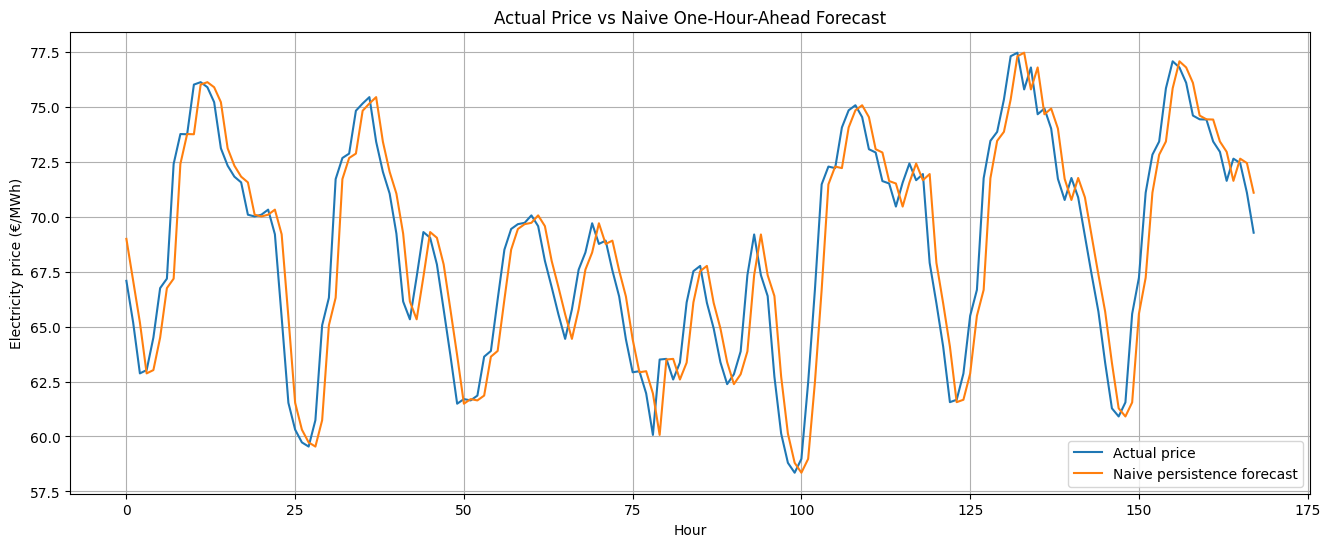

In [25]:
n_plot = 168  # First week of the test set

plt.figure(figsize=(16, 6))

plt.plot(
    y_test_inv[:n_plot],
    label="Actual price"
)

plt.plot(
    naive_forecast_inv[:n_plot],
    label="Naive persistence forecast"
)

plt.xlabel("Hour")
plt.ylabel("Electricity price (€/MWh)")
plt.title("Actual Price vs Naive One-Hour-Ahead Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [26]:
seasonal_naive_forecast = X_test[:, 0, -1].reshape(-1, 1)

seasonal_naive_forecast_inv = scaler_y.inverse_transform(
    seasonal_naive_forecast
)

rmse_seasonal_naive = np.sqrt(
    mean_squared_error(y_test_inv, seasonal_naive_forecast_inv)
)

mae_seasonal_naive = np.mean(
    np.abs(y_test_inv - seasonal_naive_forecast_inv)
)

r2_seasonal_naive = r2_score(
    y_test_inv,
    seasonal_naive_forecast_inv
)

print(f"Seasonal naive RMSE: {rmse_seasonal_naive:.3f} €/MWh")
print(f"Seasonal naive MAE: {mae_seasonal_naive:.3f} €/MWh")
print(f"Seasonal naive R²: {r2_seasonal_naive:.3f}")

Seasonal naive RMSE: 5.652 €/MWh
Seasonal naive MAE: 4.136 €/MWh
Seasonal naive R²: 0.532


In [27]:
naive_results = pd.DataFrame({
    "Model": [
        "Persistence naive",
        "24-hour seasonal naive"
    ],
    "RMSE": [
        rmse_naive,
        rmse_seasonal_naive
    ],
    "MAE": [
        mae_naive,
        mae_seasonal_naive
    ],
    "R2": [
        r2_naive,
        r2_seasonal_naive
    ]
})

naive_results

,Model,RMSE,MAE,R2
0,Persistence naive,3.116084,2.174275,0.857899
1,24-hour seasonal naive,5.652163,4.136222,0.532473


In [60]:
# XG Boost
X_train_xgb = X_train.reshape(-1, X_train.shape[1] * X_train.shape[2])
X_val_xgb = X_val.reshape(-1, X_val.shape[1] * X_val.shape[2])
X_test_xgb = X_test.reshape(-1, X_test.shape[1] * X_test.shape[2])

In [61]:
param = {'eta': 0.03, 'max_depth': 180, 
         'subsample': 1.0, 'colsample_bytree': 0.95, 
         'alpha': 0.1, 'lambda': 0.15, 'gamma': 0.1,
         'objective': 'reg:linear', 'eval_metric': 'rmse', 
         'silent': 1, 'min_child_weight': 0.1, 'n_jobs': -1}

dtrain = xgb.DMatrix(X_train_xgb, y_train)
dval = xgb.DMatrix(X_val_xgb, y_val)
dtest = xgb.DMatrix(X_test_xgb, y_test)
eval_list = [(dtrain, 'train'), (dval, 'eval')]

xgb_model = xgb.train(param, dtrain, 180, eval_list, early_stopping_rounds=3)

[0]	train-rmse:0.12945	eval-rmse:0.10910
[1]	train-rmse:0.12581	eval-rmse:0.10605
[2]	train-rmse:0.12228	eval-rmse:0.10312
[3]	train-rmse:0.11887	eval-rmse:0.10028
[4]	train-rmse:0.11556	eval-rmse:0.09751
[5]	train-rmse:0.11236	eval-rmse:0.09484
[6]	train-rmse:0.10926	eval-rmse:0.09224
[7]	train-rmse:0.10627	eval-rmse:0.08970
[8]	train-rmse:0.10336	eval-rmse:0.08726
[9]	train-rmse:0.10054	eval-rmse:0.08490
[10]	train-rmse:0.09782	eval-rmse:0.08260
[11]	train-rmse:0.09518	eval-rmse:0.08038
[12]	train-rmse:0.09263	eval-rmse:0.07827
[13]	train-rmse:0.09016	eval-rmse:0.07619
[14]	train-rmse:0.08777	eval-rmse:0.07420
[15]	train-rmse:0.08546	eval-rmse:0.07231
[16]	train-rmse:0.08323	eval-rmse:0.07048
[17]	train-rmse:0.08107	eval-rmse:0.06868
[18]	train-rmse:0.07898	eval-rmse:0.06695
[19]	train-rmse:0.07696	eval-rmse:0.06527
[20]	train-rmse:0.07500	eval-rmse:0.06366
[21]	train-rmse:0.07312	eval-rmse:0.06215
[22]	train-rmse:0.07128	eval-rmse:0.06062
[23]	train-rmse:0.06953	eval-rmse:0.05920
[2

In [62]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (27024, 24, 17)
X_val: (3984, 24, 17)
X_test: (3984, 24, 17)
y_train: (27024,)
y_val: (3984,)
y_test: (3984, 1)


In [65]:
forecast = xgb_model.predict(dtest)
xgb_forecast = forecast.reshape(-1, 1)

xgb_forecast_inv = scaler_y.inverse_transform(xgb_forecast)

rmse_xgb = np.sqrt(mean_squared_error(y_test_inv, xgb_forecast_inv))
print('RMSE of hour-ahead electricity price XGBoost forecast: {}'
      .format(round(rmse_xgb, 3)))

RMSE of hour-ahead electricity price XGBoost forecast: 2.247


In [30]:
# LSTM
tf.keras.backend.clear_session()

multivariate_lstm = tf.keras.models.Sequential([LSTM(
    100, input_shape=input_shape, return_sequences=True),
    Flatten(),
    Dense(200, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'multivariate_lstm.h5', monitor=('val_loss'), save_best_only=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=6e-3, amsgrad=True)

multivariate_lstm.compile(loss=loss,
                          optimizer=optimizer,
                          metrics=metric)

In [31]:
history = multivariate_lstm.fit(train, epochs=120,
                                validation_data=validation,
                                callbacks=[early_stopping,
                                           model_checkpoint])

Epoch 1/120


W0000 00:00:1780910798.491397    2576 cpu_allocator_impl.cc:82] Allocation of 88206336 exceeds 10% of free system memory.


844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6124 - root_mean_squared_error: 0.6033

845/845 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.1028 - root_mean_squared_error: 0.3206 - val_loss: 0.0047 - val_root_mean_squared_error: 0.0683
Epoch 2/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0054 - root_mean_squared_error: 0.0726

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0041 - root_mean_squared_error: 0.0641 - val_loss: 0.0036 - val_root_mean_squared_error: 0.0598
Epoch 3/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0039 - root_mean_squared_error: 0.0624

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0032 - root_mean_squared_error: 0.0562 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0588
Epoch 4/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0032 - root_mean_squared_error: 0.0563

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0026 - root_mean_squared_error: 0.0509 - val_loss: 0.0029 - val_root_mean_squared_error: 0.0536
Epoch 5/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0027 - root_mean_squared_error: 0.0517

845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0022 - root_mean_squared_error: 0.0471 - val_loss: 0.0028 - val_root_mean_squared_error: 0.0531
Epoch 6/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - root_mean_squared_error: 0.0487

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0020 - root_mean_squared_error: 0.0444 - val_loss: 0.0024 - val_root_mean_squared_error: 0.0486
Epoch 7/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - root_mean_squared_error: 0.0468

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0018 - root_mean_squared_error: 0.0428 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0457
Epoch 8/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0017 - root_mean_squared_error: 0.0416 - val_loss: 0.0023 - val_root_mean_squared_error: 0.0475
Epoch 9/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020 - root_mean_squared_error: 0.0442

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0016 - root_mean_squared_error: 0.0402 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0454
Epoch 10/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0018 - root_mean_squared_error: 0.0418

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0015 - root_mean_squared_error: 0.0384 - val_loss: 0.0020 - val_root_mean_squared_error: 0.0442
Epoch 11/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0014 - root_mean_squared_error: 0.0375 - val_loss: 0.0022 - val_root_mean_squared_error: 0.0470
Epoch 12/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0014 - root_mean_squared_error: 0.0368 - val_loss: 0.0023 - val_root_mean_squared_error: 0.0483
Epoch 13/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - root_mean_squared_error: 0.0392

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0013 - root_mean_squared_error: 0.0358 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0392
Epoch 14/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0013 - root_mean_squared_error: 0.0356 - val_loss: 0.0018 - val_root_mean_squared_error: 0.0421
Epoch 15/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0012 - root_mean_squared_error: 0.0352 - val_loss: 0.0017 - val_root_mean_squared_error: 0.0409
Epoch 16/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0012 - root_mean_squared_error: 0.0341 - val_loss: 0.0017 - val_root_mean_squared_error: 0.0412
Epoch 17/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0011 - root_mean_squared_error: 0.0337 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0398
Epoch 18/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - root_mean_squared_error: 0.0362

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0011 - root_mean_squared_error: 0.0329 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0385
Epoch 19/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - root_mean_squared_error: 0.0359

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0011 - root_mean_squared_error: 0.0327 - val_loss: 0.0014 - val_root_mean_squared_error: 0.0377
Epoch 20/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0011 - root_mean_squared_error: 0.0325 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0402
Epoch 21/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0010 - root_mean_squared_error: 0.0319 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0383
Epoch 22/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0010 - root_mean_squared_error: 0.0318 - val_loss: 0.0017 - val_root_mean_squared_error: 0.0417
Epoch 23/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 9.7337e-04 - root_mean_squared_error: 0.0312 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0391
Epoch 24/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 9.5696e-04 - root_mean_squared_error: 0.0309 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0383
Epoch 25/120
845/845 ━━━━━━━━━━━━

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 9.2119e-04 - root_mean_squared_error: 0.0304 - val_loss: 0.0014 - val_root_mean_squared_error: 0.0370
Epoch 27/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 9.0682e-04 - root_mean_squared_error: 0.0301 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0384
Epoch 28/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - root_mean_squared_error: 0.0326

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.8178e-04 - root_mean_squared_error: 0.0297 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0357
Epoch 29/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.7454e-04 - root_mean_squared_error: 0.0296 - val_loss: 0.0014 - val_root_mean_squared_error: 0.0371
Epoch 30/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.3747e-04 - root_mean_squared_error: 0.0289 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0366
Epoch 31/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.2044e-04 - root_mean_squared_error: 0.0286 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0359
Epoch 32/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.3424e-04 - root_mean_squared_error: 0.0289 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0361
Epoch 33/120
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.6123e-04 - root_mean_squared_error: 0.0309

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.0426e-04 - root_mean_squared_error: 0.0284 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0344
Epoch 34/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.9335e-04 - root_mean_squared_error: 0.0282 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0357
Epoch 35/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.9853e-04 - root_mean_squared_error: 0.0283 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0344
Epoch 36/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.9640e-04 - root_mean_squared_error: 0.0282 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0346
Epoch 37/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.5756e-04 - root_mean_squared_error: 0.0275 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0345
Epoch 38/120
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.0991e-04 - root_mean_squared_error: 0.0301

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.6901e-04 - root_mean_squared_error: 0.0277 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0326
Epoch 39/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.4370e-04 - root_mean_squared_error: 0.0273 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0331
Epoch 40/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.2527e-04 - root_mean_squared_error: 0.0269 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0332
Epoch 41/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.2820e-04 - root_mean_squared_error: 0.0270 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0360
Epoch 42/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.1860e-04 - root_mean_squared_error: 0.0268 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0344
Epoch 43/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.1943e-04 - root_mean_squared_error: 0.0268 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0363
Epoch 44/120
845/

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.7463e-04 - root_mean_squared_error: 0.0260 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0321
Epoch 49/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.7369e-04 - root_mean_squared_error: 0.0260 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0332
Epoch 50/120
842/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.0322e-04 - root_mean_squared_error: 0.0283

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.6984e-04 - root_mean_squared_error: 0.0259 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0319
Epoch 51/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.8617e-04 - root_mean_squared_error: 0.0279

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.6433e-04 - root_mean_squared_error: 0.0258 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0317
Epoch 52/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.4265e-04 - root_mean_squared_error: 0.0254 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0328
Epoch 53/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.8885e-04 - root_mean_squared_error: 0.0280

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.4897e-04 - root_mean_squared_error: 0.0255 - val_loss: 9.7792e-04 - val_root_mean_squared_error: 0.0313
Epoch 54/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.4281e-04 - root_mean_squared_error: 0.0254 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0319
Epoch 55/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.4550e-04 - root_mean_squared_error: 0.0254 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0331
Epoch 56/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.4242e-04 - root_mean_squared_error: 0.0272

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.2997e-04 - root_mean_squared_error: 0.0251 - val_loss: 9.4711e-04 - val_root_mean_squared_error: 0.0308
Epoch 57/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.2939e-04 - root_mean_squared_error: 0.0251 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0334
Epoch 58/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.1701e-04 - root_mean_squared_error: 0.0248 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0336
Epoch 59/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.1441e-04 - root_mean_squared_error: 0.0248 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0318
Epoch 60/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.1245e-04 - root_mean_squared_error: 0.0247 - val_loss: 9.9336e-04 - val_root_mean_squared_error: 0.0315
Epoch 61/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.2611e-04 - root_mean_squared_error: 0.0269

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.1028e-04 - root_mean_squared_error: 0.0247 - val_loss: 9.3163e-04 - val_root_mean_squared_error: 0.0305
Epoch 62/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.1165e-04 - root_mean_squared_error: 0.0247 - val_loss: 9.8380e-04 - val_root_mean_squared_error: 0.0314
Epoch 63/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.8962e-04 - root_mean_squared_error: 0.0243 - val_loss: 9.5568e-04 - val_root_mean_squared_error: 0.0309
Epoch 64/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.8357e-04 - root_mean_squared_error: 0.0242 - val_loss: 9.3825e-04 - val_root_mean_squared_error: 0.0306
Epoch 65/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.8748e-04 - root_mean_squared_error: 0.0242 - val_loss: 9.9882e-04 - val_root_mean_squared_error: 0.0316
Epoch 66/120
842/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.9217e-04 - root_mean_squared_error: 0.0262

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.7777e-04 - root_mean_squared_error: 0.0240 - val_loss: 8.8262e-04 - val_root_mean_squared_error: 0.0297
Epoch 67/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.8568e-04 - root_mean_squared_error: 0.0242 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0316
Epoch 68/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.7570e-04 - root_mean_squared_error: 0.0240 - val_loss: 9.2289e-04 - val_root_mean_squared_error: 0.0304
Epoch 69/120
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.6061e-04 - root_mean_squared_error: 0.0256

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.5983e-04 - root_mean_squared_error: 0.0237 - val_loss: 8.5597e-04 - val_root_mean_squared_error: 0.0293
Epoch 70/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.5661e-04 - root_mean_squared_error: 0.0236 - val_loss: 9.2762e-04 - val_root_mean_squared_error: 0.0305
Epoch 71/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.6034e-04 - root_mean_squared_error: 0.0237 - val_loss: 9.7034e-04 - val_root_mean_squared_error: 0.0312
Epoch 72/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.6211e-04 - root_mean_squared_error: 0.0237 - val_loss: 9.5943e-04 - val_root_mean_squared_error: 0.0310
Epoch 73/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.5879e-04 - root_mean_squared_error: 0.0236 - val_loss: 8.7817e-04 - val_root_mean_squared_error: 0.0296
Epoch 74/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 5.4173e-04 - root_mean_squared_error: 0.0233 - val_loss: 8.8779e-04 - val_root_mean_squared_error: 

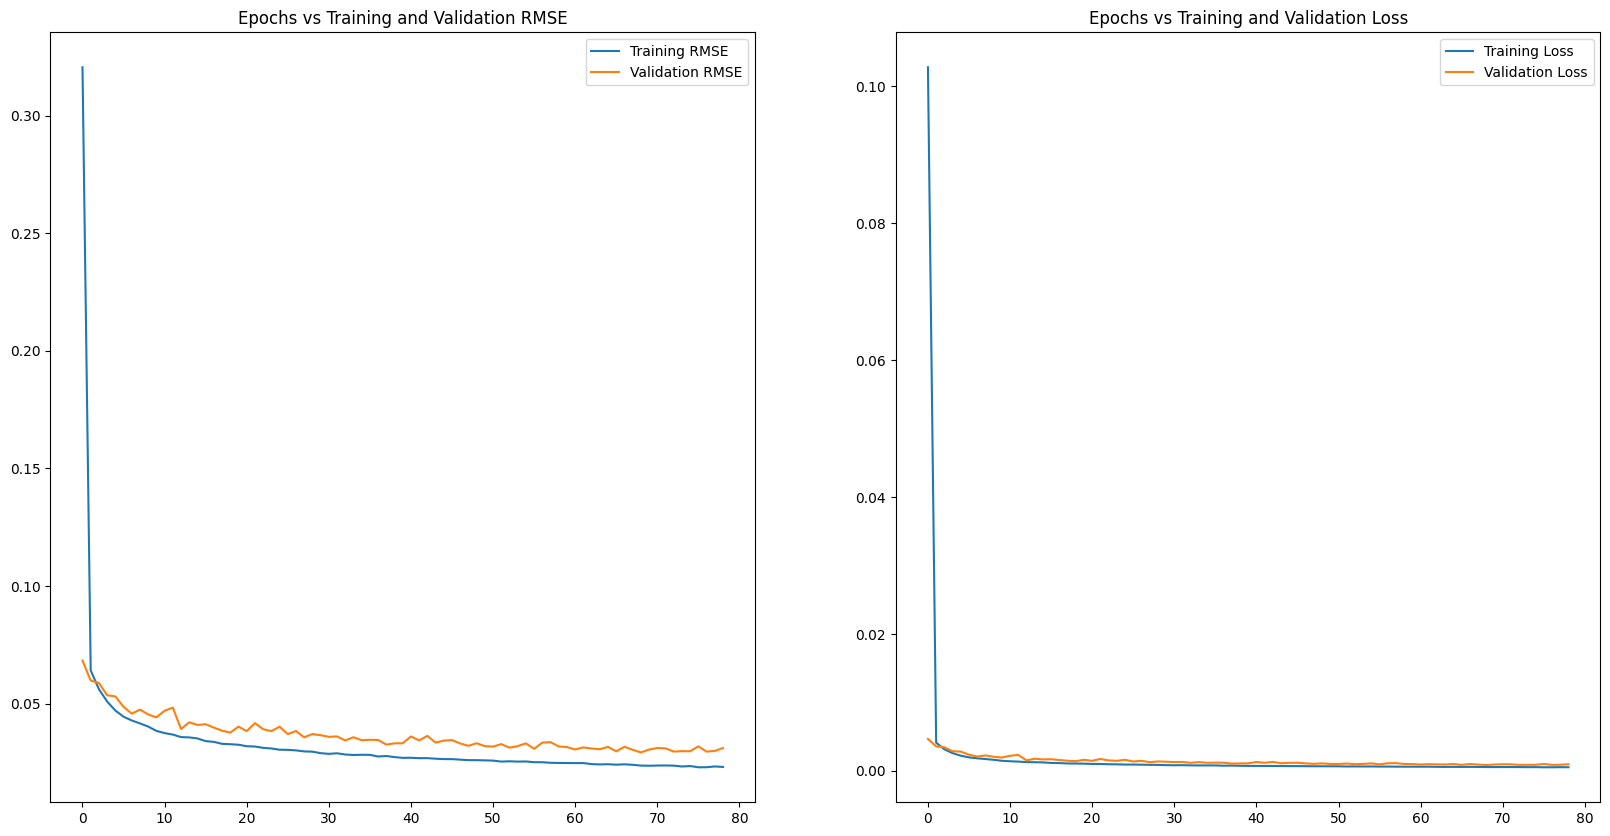

In [32]:
plot_model_rmse_and_loss(history)

In [34]:
multivariate_lstm = tf.keras.models.load_model('multivariate_lstm.h5')

forecast = multivariate_lstm.predict(X_test)
lstm_forecast = scaler_y.inverse_transform(forecast)

rmse_lstm = np.sqrt(mean_squared_error(y_test_inv,
                                    lstm_forecast))
print('RMSE of hour-ahead electricity price LSTM forecast: {}'
      .format(round(rmse_lstm, 3)))

 31/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE of hour-ahead electricity price LSTM forecast: 2.902


In [28]:
# Stacked LSTM
tf.keras.backend.clear_session()

multivariate_stacked_lstm = tf.keras.models.Sequential([
    LSTM(250, input_shape=input_shape,
         return_sequences=True),
         LSTM(150, return_sequences=True),
         Flatten(),
         Dense(150, activation='relu'),
         Dropout(0.1),
         Dense(1),
])

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'multivariate_stacked_lstm.h5', save_best_only=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-3, amsgrad=True)

multivariate_stacked_lstm.compile(loss=loss,
                                  optimizer=optimizer,
                                  metrics=metric)

In [29]:
history = multivariate_stacked_lstm.fit(train, epochs=120,
                                        validation_data=validation,
                                        callbacks=[early_stopping,
                                                   model_checkpoint])

Epoch 1/120


W0000 00:00:1780933488.328009    2718 cpu_allocator_impl.cc:82] Allocation of 88206336 exceeds 10% of free system memory.


844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1071 - root_mean_squared_error: 0.2653

845/845 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - loss: 0.0227 - root_mean_squared_error: 0.1507 - val_loss: 0.0049 - val_root_mean_squared_error: 0.0701
Epoch 2/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0046 - root_mean_squared_error: 0.0672

845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 0.0037 - root_mean_squared_error: 0.0606 - val_loss: 0.0038 - val_root_mean_squared_error: 0.0615
Epoch 3/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0035 - root_mean_squared_error: 0.0590

845/845 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - loss: 0.0029 - root_mean_squared_error: 0.0536 - val_loss: 0.0029 - val_root_mean_squared_error: 0.0537
Epoch 4/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - loss: 0.0024 - root_mean_squared_error: 0.0486 - val_loss: 0.0031 - val_root_mean_squared_error: 0.0553
Epoch 5/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0025 - root_mean_squared_error: 0.0495

845/845 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - loss: 0.0020 - root_mean_squared_error: 0.0447 - val_loss: 0.0023 - val_root_mean_squared_error: 0.0476
Epoch 6/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0021 - root_mean_squared_error: 0.0459

845/845 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - loss: 0.0017 - root_mean_squared_error: 0.0416 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0462
Epoch 7/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0018 - root_mean_squared_error: 0.0417

845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 0.0014 - root_mean_squared_error: 0.0380 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0395
Epoch 8/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0015 - root_mean_squared_error: 0.0383

845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 0.0012 - root_mean_squared_error: 0.0350 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0339
Epoch 9/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0013 - root_mean_squared_error: 0.0360

845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 0.0011 - root_mean_squared_error: 0.0331 - val_loss: 8.7566e-04 - val_root_mean_squared_error: 0.0296
Epoch 10/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 0.0010 - root_mean_squared_error: 0.0319 - val_loss: 9.0646e-04 - val_root_mean_squared_error: 0.0301
Epoch 11/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 9.2897e-04 - root_mean_squared_error: 0.0305 - val_loss: 9.5223e-04 - val_root_mean_squared_error: 0.0309
Epoch 12/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0010 - root_mean_squared_error: 0.0322

845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 8.9118e-04 - root_mean_squared_error: 0.0299 - val_loss: 8.0898e-04 - val_root_mean_squared_error: 0.0284
Epoch 13/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 9.7519e-04 - root_mean_squared_error: 0.0311

845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 8.1900e-04 - root_mean_squared_error: 0.0286 - val_loss: 7.0520e-04 - val_root_mean_squared_error: 0.0266
Epoch 14/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 9.2660e-04 - root_mean_squared_error: 0.0303

845/845 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - loss: 7.9967e-04 - root_mean_squared_error: 0.0283 - val_loss: 6.7577e-04 - val_root_mean_squared_error: 0.0260
Epoch 15/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 7.8779e-04 - root_mean_squared_error: 0.0281 - val_loss: 8.0868e-04 - val_root_mean_squared_error: 0.0284
Epoch 16/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 9.0345e-04 - root_mean_squared_error: 0.0300

845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 7.5306e-04 - root_mean_squared_error: 0.0274 - val_loss: 6.1116e-04 - val_root_mean_squared_error: 0.0247
Epoch 17/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 7.4097e-04 - root_mean_squared_error: 0.0272 - val_loss: 7.1466e-04 - val_root_mean_squared_error: 0.0267
Epoch 18/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - loss: 7.2029e-04 - root_mean_squared_error: 0.0268 - val_loss: 6.1530e-04 - val_root_mean_squared_error: 0.0248
Epoch 19/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 7.0942e-04 - root_mean_squared_error: 0.0266 - val_loss: 6.5557e-04 - val_root_mean_squared_error: 0.0256
Epoch 20/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - loss: 6.9394e-04 - root_mean_squared_error: 0.0263 - val_loss: 6.5879e-04 - val_root_mean_squared_error: 0.0257
Epoch 21/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 6.8920e-04 - root_mean_squared_error: 0.0263 - val_loss: 6.3170e-04 - val_root_mean_squared_error: 

845/845 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - loss: 6.6928e-04 - root_mean_squared_error: 0.0259 - val_loss: 5.8569e-04 - val_root_mean_squared_error: 0.0242
Epoch 24/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 6.4862e-04 - root_mean_squared_error: 0.0255 - val_loss: 5.9040e-04 - val_root_mean_squared_error: 0.0243
Epoch 25/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 6.4881e-04 - root_mean_squared_error: 0.0255 - val_loss: 6.4191e-04 - val_root_mean_squared_error: 0.0253
Epoch 26/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.4494e-04 - root_mean_squared_error: 0.0272

845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 6.3326e-04 - root_mean_squared_error: 0.0252 - val_loss: 5.7639e-04 - val_root_mean_squared_error: 0.0240
Epoch 27/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 6.2314e-04 - root_mean_squared_error: 0.0250 - val_loss: 6.5198e-04 - val_root_mean_squared_error: 0.0255
Epoch 28/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - loss: 6.2345e-04 - root_mean_squared_error: 0.0250 - val_loss: 5.8511e-04 - val_root_mean_squared_error: 0.0242
Epoch 29/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.2028e-04 - root_mean_squared_error: 0.0268

845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 6.1722e-04 - root_mean_squared_error: 0.0248 - val_loss: 5.7486e-04 - val_root_mean_squared_error: 0.0240
Epoch 30/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 6.1757e-04 - root_mean_squared_error: 0.0249 - val_loss: 6.0635e-04 - val_root_mean_squared_error: 0.0246
Epoch 31/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 6.0664e-04 - root_mean_squared_error: 0.0246 - val_loss: 6.2019e-04 - val_root_mean_squared_error: 0.0249
Epoch 32/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 5.9648e-04 - root_mean_squared_error: 0.0244 - val_loss: 5.8828e-04 - val_root_mean_squared_error: 0.0243
Epoch 33/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 6.0411e-04 - root_mean_squared_error: 0.0246 - val_loss: 6.0265e-04 - val_root_mean_squared_error: 0.0245
Epoch 34/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 6.9892e-04 - root_mean_squared_error: 0.0263

845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 5.8214e-04 - root_mean_squared_error: 0.0241 - val_loss: 5.3661e-04 - val_root_mean_squared_error: 0.0232
Epoch 35/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 5.8482e-04 - root_mean_squared_error: 0.0242 - val_loss: 5.8688e-04 - val_root_mean_squared_error: 0.0242
Epoch 36/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 5.7942e-04 - root_mean_squared_error: 0.0241 - val_loss: 6.3525e-04 - val_root_mean_squared_error: 0.0252
Epoch 37/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 5.8437e-04 - root_mean_squared_error: 0.0242 - val_loss: 6.1062e-04 - val_root_mean_squared_error: 0.0247
Epoch 38/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - loss: 5.6984e-04 - root_mean_squared_error: 0.0239 - val_loss: 6.2155e-04 - val_root_mean_squared_error: 0.0249
Epoch 39/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 5.7381e-04 - root_mean_squared_error: 0.0240 - val_loss: 7.0376e-04 - val_root_mean_squared_error: 

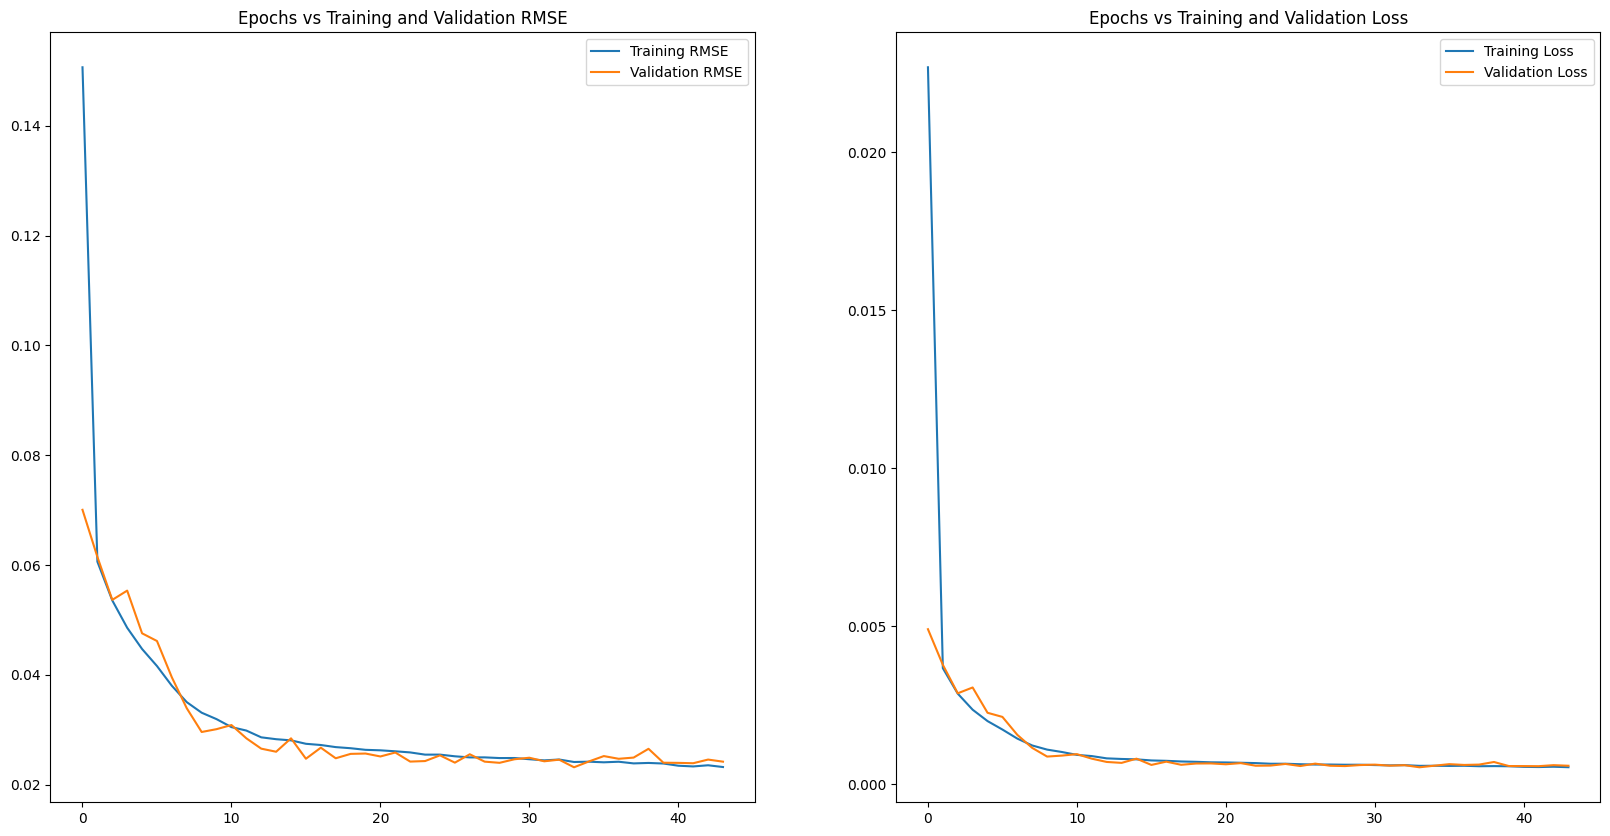

In [30]:
plot_model_rmse_and_loss(history)

In [29]:
multivariate_stacked_lstm = tf.keras.models.load_model('multivariate_stacked_lstm.h5')

forecast = multivariate_stacked_lstm.predict(X_test)
multivariate_stacked_lstm_forecast = scaler_y.inverse_transform(forecast)

rmse_mult_stacked_lstm = np.sqrt(mean_squared_error(y_test_inv,
                                                    multivariate_stacked_lstm_forecast))
print('RMSE of hour-ahead electricity price multivariate Stacked LSTM forecast: {}'
      .format(round(rmse_mult_stacked_lstm, 3)))

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
RMSE of hour-ahead electricity price multivariate Stacked LSTM forecast: 2.178


In [31]:
print(type(multivariate_stacked_lstm_forecast))
print(multivariate_stacked_lstm_forecast.shape)

<class 'numpy.ndarray'>
(3984, 1)


In [29]:
# CNN
tf.keras.backend.clear_session()

multivariate_cnn = tf.keras.models.Sequential([
    Conv1D(filters=48, kernel_size=2,
           strides=1, padding='causal',
           activation='relu', 
           input_shape=input_shape),
    Flatten(),
    Dense(48, activation='relu'),
    Dense(1)
])

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
                   'multivariate_cnn.h5', save_best_only=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=6e-3, amsgrad=True)

multivariate_cnn.compile(loss=loss,
                          optimizer=optimizer,
                          metrics=metric)

In [30]:
history = multivariate_cnn.fit(train, epochs=120,
                               validation_data=validation,
                               callbacks=[early_stopping, 
                                          model_checkpoint])

Epoch 1/120


W0000 00:00:1780935801.182845   30233 cpu_allocator_impl.cc:82] Allocation of 88206336 exceeds 10% of free system memory.


828/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1654 - root_mean_squared_error: 0.3198

845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0296 - root_mean_squared_error: 0.1722 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0592
Epoch 2/120
831/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - root_mean_squared_error: 0.0545

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0022 - root_mean_squared_error: 0.0472 - val_loss: 0.0031 - val_root_mean_squared_error: 0.0554
Epoch 3/120
820/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0023 - root_mean_squared_error: 0.0473

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0018 - root_mean_squared_error: 0.0422 - val_loss: 0.0022 - val_root_mean_squared_error: 0.0465
Epoch 4/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0015 - root_mean_squared_error: 0.0385 - val_loss: 0.0025 - val_root_mean_squared_error: 0.0496
Epoch 5/120
840/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017 - root_mean_squared_error: 0.0410

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0013 - root_mean_squared_error: 0.0365 - val_loss: 0.0017 - val_root_mean_squared_error: 0.0413
Epoch 6/120
831/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0012 - root_mean_squared_error: 0.0340

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.2001e-04 - root_mean_squared_error: 0.0303 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0365
Epoch 7/120
827/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.7995e-04 - root_mean_squared_error: 0.0311

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.7320e-04 - root_mean_squared_error: 0.0278 - val_loss: 9.5678e-04 - val_root_mean_squared_error: 0.0309
Epoch 8/120
827/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.6404e-04 - root_mean_squared_error: 0.0292

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.9497e-04 - root_mean_squared_error: 0.0264 - val_loss: 7.6552e-04 - val_root_mean_squared_error: 0.0277
Epoch 9/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.8461e-04 - root_mean_squared_error: 0.0278

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.3964e-04 - root_mean_squared_error: 0.0253 - val_loss: 7.1701e-04 - val_root_mean_squared_error: 0.0268
Epoch 10/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.0824e-04 - root_mean_squared_error: 0.0247 - val_loss: 7.7019e-04 - val_root_mean_squared_error: 0.0278
Epoch 11/120
822/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0198e-04 - root_mean_squared_error: 0.0264

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.0520e-04 - root_mean_squared_error: 0.0246 - val_loss: 7.0530e-04 - val_root_mean_squared_error: 0.0266
Epoch 12/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.8366e-04 - root_mean_squared_error: 0.0242 - val_loss: 7.0864e-04 - val_root_mean_squared_error: 0.0266
Epoch 13/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.6617e-04 - root_mean_squared_error: 0.0238 - val_loss: 8.1463e-04 - val_root_mean_squared_error: 0.0285
Epoch 14/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6507e-04 - root_mean_squared_error: 0.0257

845/845 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.6245e-04 - root_mean_squared_error: 0.0237 - val_loss: 6.8846e-04 - val_root_mean_squared_error: 0.0262
Epoch 15/120
815/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7001e-04 - root_mean_squared_error: 0.0258

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.5896e-04 - root_mean_squared_error: 0.0236 - val_loss: 6.5290e-04 - val_root_mean_squared_error: 0.0256
Epoch 16/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.6111e-04 - root_mean_squared_error: 0.0237 - val_loss: 7.0294e-04 - val_root_mean_squared_error: 0.0265
Epoch 17/120
826/845 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3096e-04 - root_mean_squared_error: 0.0250

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.4068e-04 - root_mean_squared_error: 0.0233 - val_loss: 5.7862e-04 - val_root_mean_squared_error: 0.0241
Epoch 18/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.4244e-04 - root_mean_squared_error: 0.0233 - val_loss: 6.1478e-04 - val_root_mean_squared_error: 0.0248
Epoch 19/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.3333e-04 - root_mean_squared_error: 0.0231 - val_loss: 5.9029e-04 - val_root_mean_squared_error: 0.0243
Epoch 20/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.2959e-04 - root_mean_squared_error: 0.0230 - val_loss: 6.0598e-04 - val_root_mean_squared_error: 0.0246
Epoch 21/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.2498e-04 - root_mean_squared_error: 0.0229 - val_loss: 6.1727e-04 - val_root_mean_squared_error: 0.0248
Epoch 22/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.1600e-04 - root_mean_squared_error: 0.0227 - val_loss: 6.1897e-04 - val_root_mean_squared_error: 0.0249
Epoch

845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.1821e-04 - root_mean_squared_error: 0.0228 - val_loss: 5.3897e-04 - val_root_mean_squared_error: 0.0232
Epoch 28/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.1496e-04 - root_mean_squared_error: 0.0227 - val_loss: 5.9607e-04 - val_root_mean_squared_error: 0.0244
Epoch 29/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.9844e-04 - root_mean_squared_error: 0.0223 - val_loss: 5.5816e-04 - val_root_mean_squared_error: 0.0236
Epoch 30/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.0738e-04 - root_mean_squared_error: 0.0225 - val_loss: 5.9609e-04 - val_root_mean_squared_error: 0.0244
Epoch 31/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.0229e-04 - root_mean_squared_error: 0.0224 - val_loss: 6.9643e-04 - val_root_mean_squared_error: 0.0264
Epoch 32/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.0804e-04 - root_mean_squared_error: 0.0225 - val_loss: 6.1926e-04 - val_root_mean_squared_error: 0.0249
Epoch

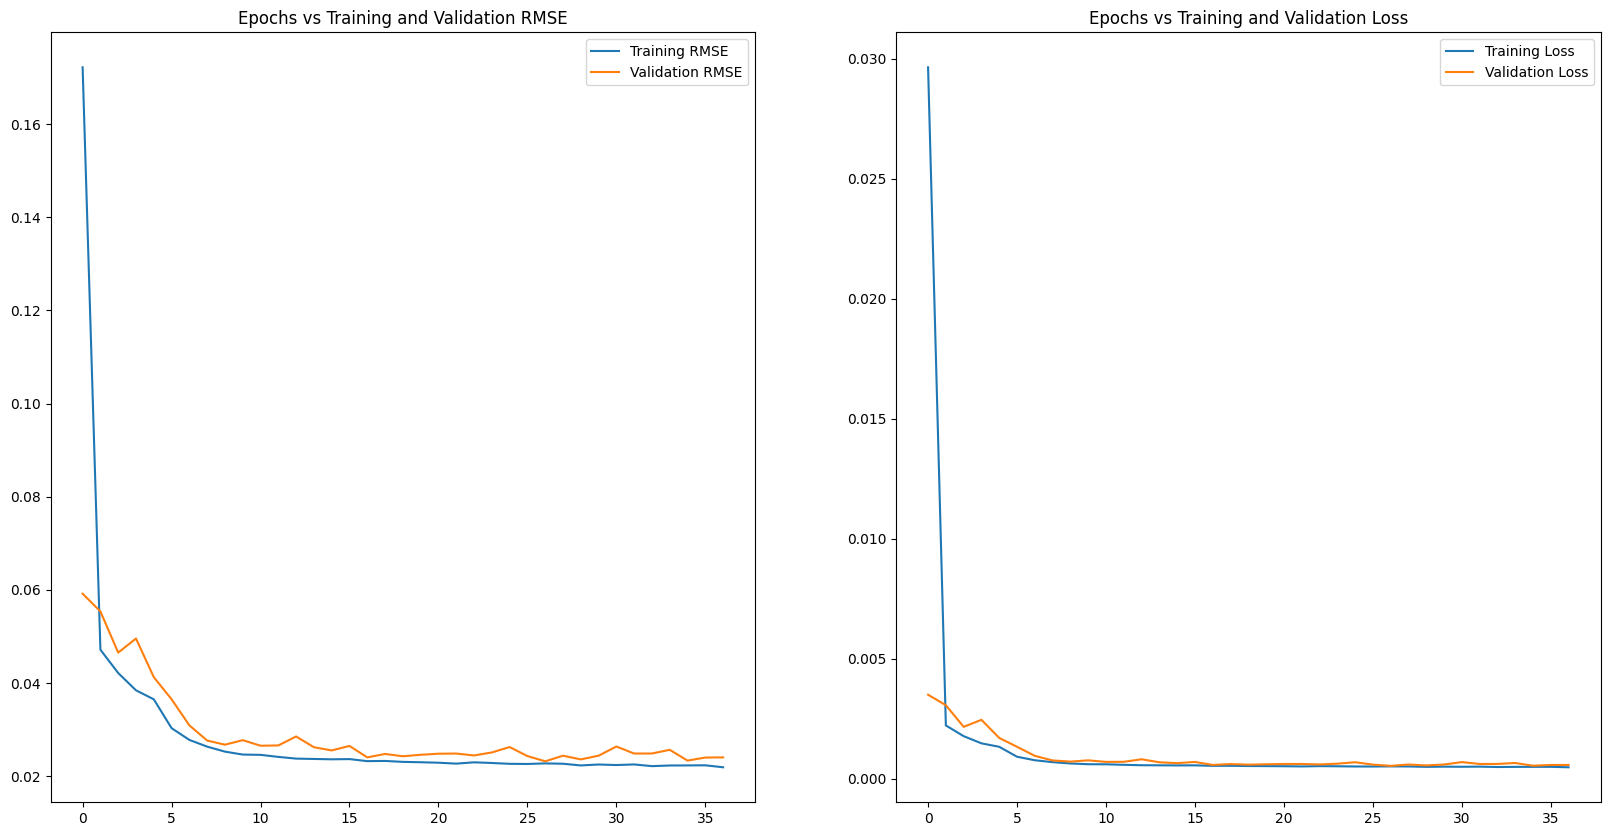

In [31]:
plot_model_rmse_and_loss(history)

In [33]:
multivariate_cnn = tf.keras.models.load_model('multivariate_cnn.h5')

forecast = multivariate_cnn.predict(X_test)
multivariate_cnn_forecast = scaler_y.inverse_transform(forecast)

rmse_mult_cnn = np.sqrt(mean_squared_error(y_test_inv,
                                        multivariate_cnn_forecast))
print('RMSE of hour-ahead electricity price multivariate CNN forecast: {}'
      .format(round(rmse_mult_cnn, 3)))

106/125 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
RMSE of hour-ahead electricity price multivariate CNN forecast: 2.228


In [34]:
# CNN - LSTM
tf.keras.backend.clear_session()

multivariate_cnn_lstm = tf.keras.models.Sequential([
    Conv1D(filters=100, kernel_size=2,
           strides=1, padding='causal',
           activation='relu', 
           input_shape=input_shape),
    LSTM(100, return_sequences=True),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
                   'multivariate_cnn_lstm.h5', save_best_only=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=4e-3, amsgrad=True)

multivariate_cnn_lstm.compile(loss=loss,
                          optimizer=optimizer,
                          metrics=metric)

In [35]:
history = multivariate_cnn_lstm.fit(train, epochs=120,
                                    validation_data=validation,
                                    callbacks=[early_stopping, 
                                               model_checkpoint])

Epoch 1/120
842/845 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0307 - root_mean_squared_error: 0.1115

845/845 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0082 - root_mean_squared_error: 0.0850 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0593
Epoch 2/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0023 - root_mean_squared_error: 0.0470

845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0015 - root_mean_squared_error: 0.0392 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0396
Epoch 3/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - root_mean_squared_error: 0.0355

845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 9.7164e-04 - root_mean_squared_error: 0.0312 - val_loss: 9.2181e-04 - val_root_mean_squared_error: 0.0304
Epoch 4/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9985e-04 - root_mean_squared_error: 0.0298

845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 7.2331e-04 - root_mean_squared_error: 0.0269 - val_loss: 7.9773e-04 - val_root_mean_squared_error: 0.0282
Epoch 5/120
844/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.1279e-04 - root_mean_squared_error: 0.0283

845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 6.4661e-04 - root_mean_squared_error: 0.0254 - val_loss: 6.6406e-04 - val_root_mean_squared_error: 0.0258
Epoch 6/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 6.0519e-04 - root_mean_squared_error: 0.0246 - val_loss: 7.9351e-04 - val_root_mean_squared_error: 0.0282
Epoch 7/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5.6539e-04 - root_mean_squared_error: 0.0238 - val_loss: 7.4133e-04 - val_root_mean_squared_error: 0.0272
Epoch 8/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5.4662e-04 - root_mean_squared_error: 0.0234 - val_loss: 6.8725e-04 - val_root_mean_squared_error: 0.0262
Epoch 9/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3722e-04 - root_mean_squared_error: 0.0251

845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5.2824e-04 - root_mean_squared_error: 0.0230 - val_loss: 6.3527e-04 - val_root_mean_squared_error: 0.0252
Epoch 10/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.5543e-04 - root_mean_squared_error: 0.0255

845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5.3831e-04 - root_mean_squared_error: 0.0232 - val_loss: 6.2291e-04 - val_root_mean_squared_error: 0.0250


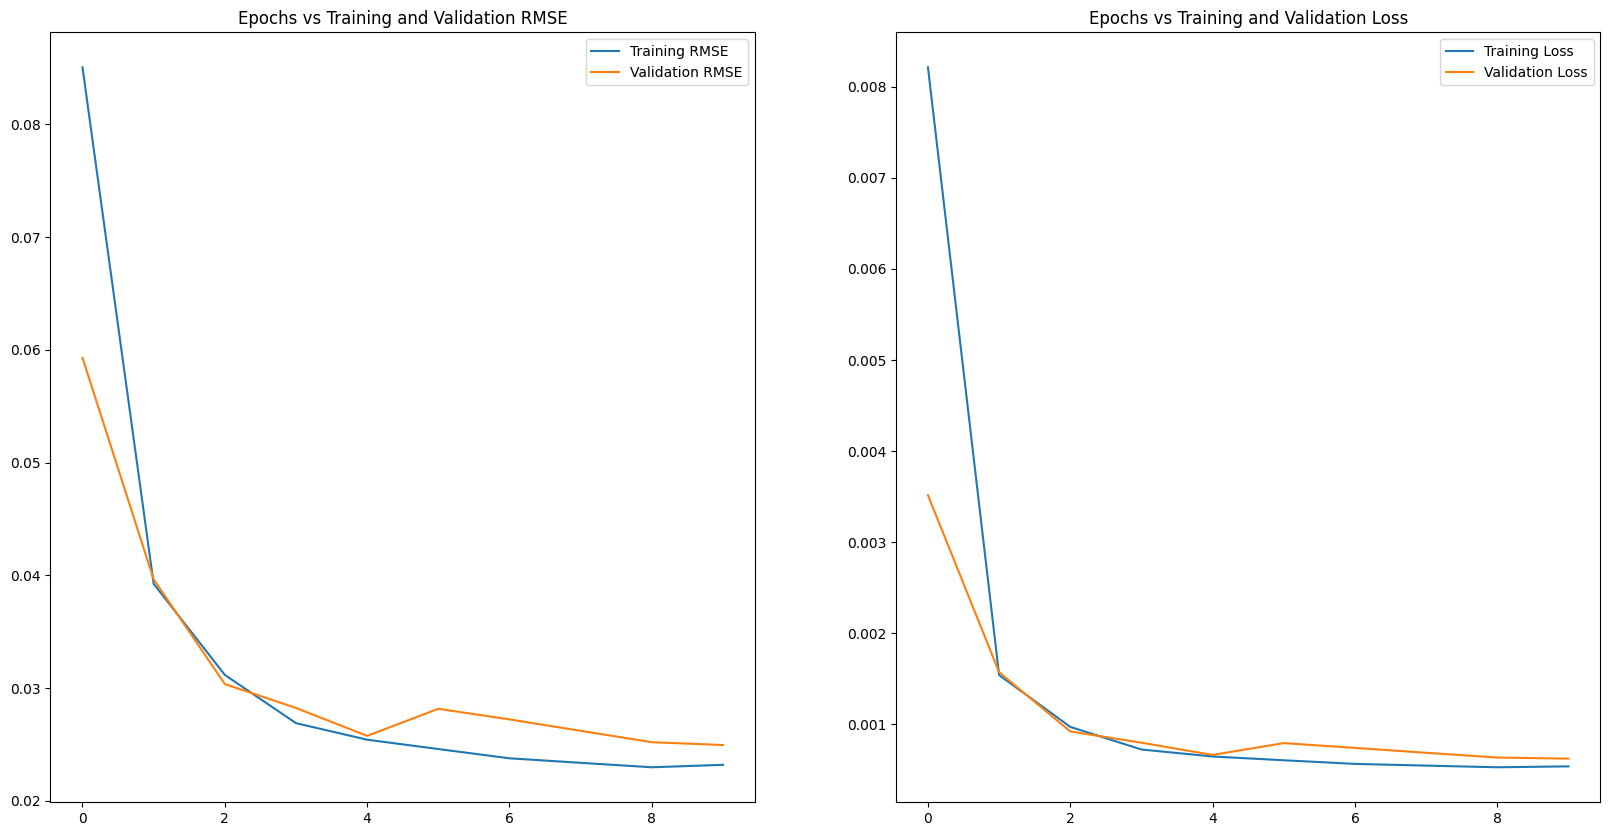

In [36]:
plot_model_rmse_and_loss(history)

In [38]:
multivariate_cnn_lstm = tf.keras.models.load_model('multivariate_cnn_lstm.h5')

forecast = multivariate_cnn_lstm.predict(X_test)
multivariate_cnn_lstm_forecast = scaler_y.inverse_transform(forecast)

rmse_mult_cnn_lstm = np.sqrt(mean_squared_error(y_test_inv, 
                                             multivariate_cnn_lstm_forecast))
print('RMSE of hour-ahead electricity price multivariate CNN-`LSTM forecast: {}'
      .format(round(rmse_mult_cnn_lstm, 3)))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RMSE of hour-ahead electricity price multivariate CNN-`LSTM forecast: 2.415


In [39]:
X_test.shape

(3984, 24, 17)

In [41]:
# Time distributed MLP
tf.keras.backend.clear_session()

multivariate_mlp = tf.keras.models.Sequential([
    TimeDistributed(Dense(200, activation='relu'),
                    input_shape=input_shape),
    TimeDistributed(Dense(150, activation='relu')),
    TimeDistributed(Dense(100, activation='relu')),
    TimeDistributed(Dense(50, activation='relu')),
    Flatten(),
    Dense(150, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
                   'multivariate_mlp.h5', save_best_only=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-3, amsgrad=True)

multivariate_mlp.compile(loss=loss,
                          optimizer=optimizer,
                          metrics=metric)

In [42]:
history = multivariate_mlp.fit(train, epochs=120,
                               validation_data=validation,
                               callbacks=[early_stopping, 
                                          model_checkpoint])

Epoch 1/120
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0179 - root_mean_squared_error: 0.0887

845/845 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0058 - root_mean_squared_error: 0.0714 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0588
Epoch 2/120
842/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0026 - root_mean_squared_error: 0.0503

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0019 - root_mean_squared_error: 0.0431 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0389
Epoch 3/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0013 - root_mean_squared_error: 0.0363 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0462
Epoch 4/120
842/845 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - root_mean_squared_error: 0.0360

845/845 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0011 - root_mean_squared_error: 0.0324 - val_loss: 8.3979e-04 - val_root_mean_squared_error: 0.0290
Epoch 5/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 9.3552e-04 - root_mean_squared_error: 0.0306 - val_loss: 8.5199e-04 - val_root_mean_squared_error: 0.0292
Epoch 6/120
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.8100e-04 - root_mean_squared_error: 0.0312

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 8.2569e-04 - root_mean_squared_error: 0.0287 - val_loss: 7.9151e-04 - val_root_mean_squared_error: 0.0281
Epoch 7/120
841/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.9902e-04 - root_mean_squared_error: 0.0299

845/845 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 7.7057e-04 - root_mean_squared_error: 0.0278 - val_loss: 7.0538e-04 - val_root_mean_squared_error: 0.0266
Epoch 8/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 7.2366e-04 - root_mean_squared_error: 0.0269 - val_loss: 7.5431e-04 - val_root_mean_squared_error: 0.0275
Epoch 9/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 7.0704e-04 - root_mean_squared_error: 0.0266 - val_loss: 8.0549e-04 - val_root_mean_squared_error: 0.0284
Epoch 10/120
845/845 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 6.4563e-04 - root_mean_squared_error: 0.0254 - val_loss: 7.2531e-04 - val_root_mean_squared_error: 0.0269


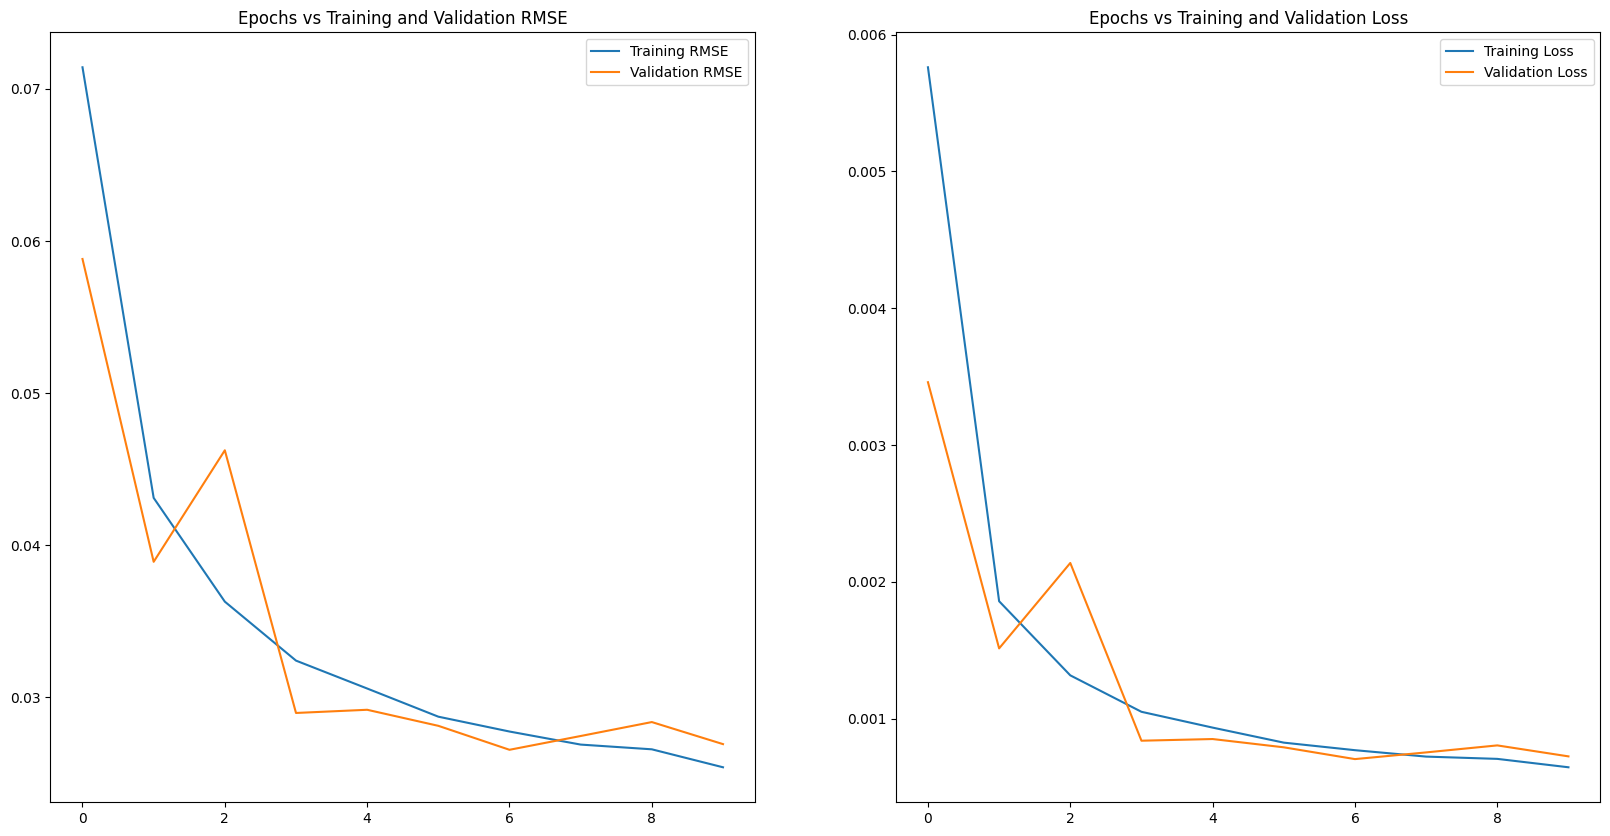

In [43]:
plot_model_rmse_and_loss(history)

In [45]:
multivariate_mlp = tf.keras.models.load_model('multivariate_mlp.h5')

forecast = multivariate_mlp.predict(X_test)
multivariate_mlp_forecast = scaler_y.inverse_transform(forecast)

rmse_mult_mlp = np.sqrt(mean_squared_error(y_test_inv,
                                        multivariate_mlp_forecast))
print('RMSE of hour-ahead electricity price multivariate MLP forecast: {}'
      .format(round(rmse_mult_mlp, 3)))

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RMSE of hour-ahead electricity price multivariate MLP forecast: 2.473


In [46]:
# Encoder-Decoder
tf.keras.backend.clear_session()

encoder_decoder = tf.keras.models.Sequential([
    LSTM(50, activation='relu', input_shape=input_shape),
    RepeatVector(past_history),
    LSTM(50, activation='relu', return_sequences=True),
    TimeDistributed(Dense(50, activation='relu')),
    Flatten(),
    Dense(25, activation='relu'),
    Dense(1)
])



model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
                   'encoder_decoder.h5', save_best_only=True)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, amsgrad=True)

encoder_decoder.compile(loss=loss,
                    optimizer=optimizer,
                    metrics=metric)

In [47]:
history = encoder_decoder.fit(train, epochs=50,
                              validation_data=validation,
                              callbacks=[early_stopping, 
                                         model_checkpoint])

Epoch 1/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0100 - root_mean_squared_error: 0.0715

845/845 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0040 - root_mean_squared_error: 0.0598 - val_loss: 0.0050 - val_root_mean_squared_error: 0.0706
Epoch 2/50
843/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0020 - root_mean_squared_error: 0.0441

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0014 - root_mean_squared_error: 0.0377 - val_loss: 0.0014 - val_root_mean_squared_error: 0.0375
Epoch 3/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0014 - root_mean_squared_error: 0.0373

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0011 - root_mean_squared_error: 0.0325 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0344
Epoch 4/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.5620e-04 - root_mean_squared_error: 0.0293 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0384
Epoch 5/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - root_mean_squared_error: 0.0323

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.0598e-04 - root_mean_squared_error: 0.0284 - val_loss: 7.8762e-04 - val_root_mean_squared_error: 0.0281
Epoch 6/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.8127e-04 - root_mean_squared_error: 0.0261 - val_loss: 8.0485e-04 - val_root_mean_squared_error: 0.0284
Epoch 7/50
842/845 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.1305e-04 - root_mean_squared_error: 0.0283

845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.5531e-04 - root_mean_squared_error: 0.0256 - val_loss: 6.7745e-04 - val_root_mean_squared_error: 0.0260
Epoch 8/50
842/845 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.8033e-04 - root_mean_squared_error: 0.0278

845/845 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 6.4193e-04 - root_mean_squared_error: 0.0253 - val_loss: 6.0639e-04 - val_root_mean_squared_error: 0.0246
Epoch 9/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.0373e-04 - root_mean_squared_error: 0.0246 - val_loss: 7.2027e-04 - val_root_mean_squared_error: 0.0268
Epoch 10/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.0073e-04 - root_mean_squared_error: 0.0245 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0349


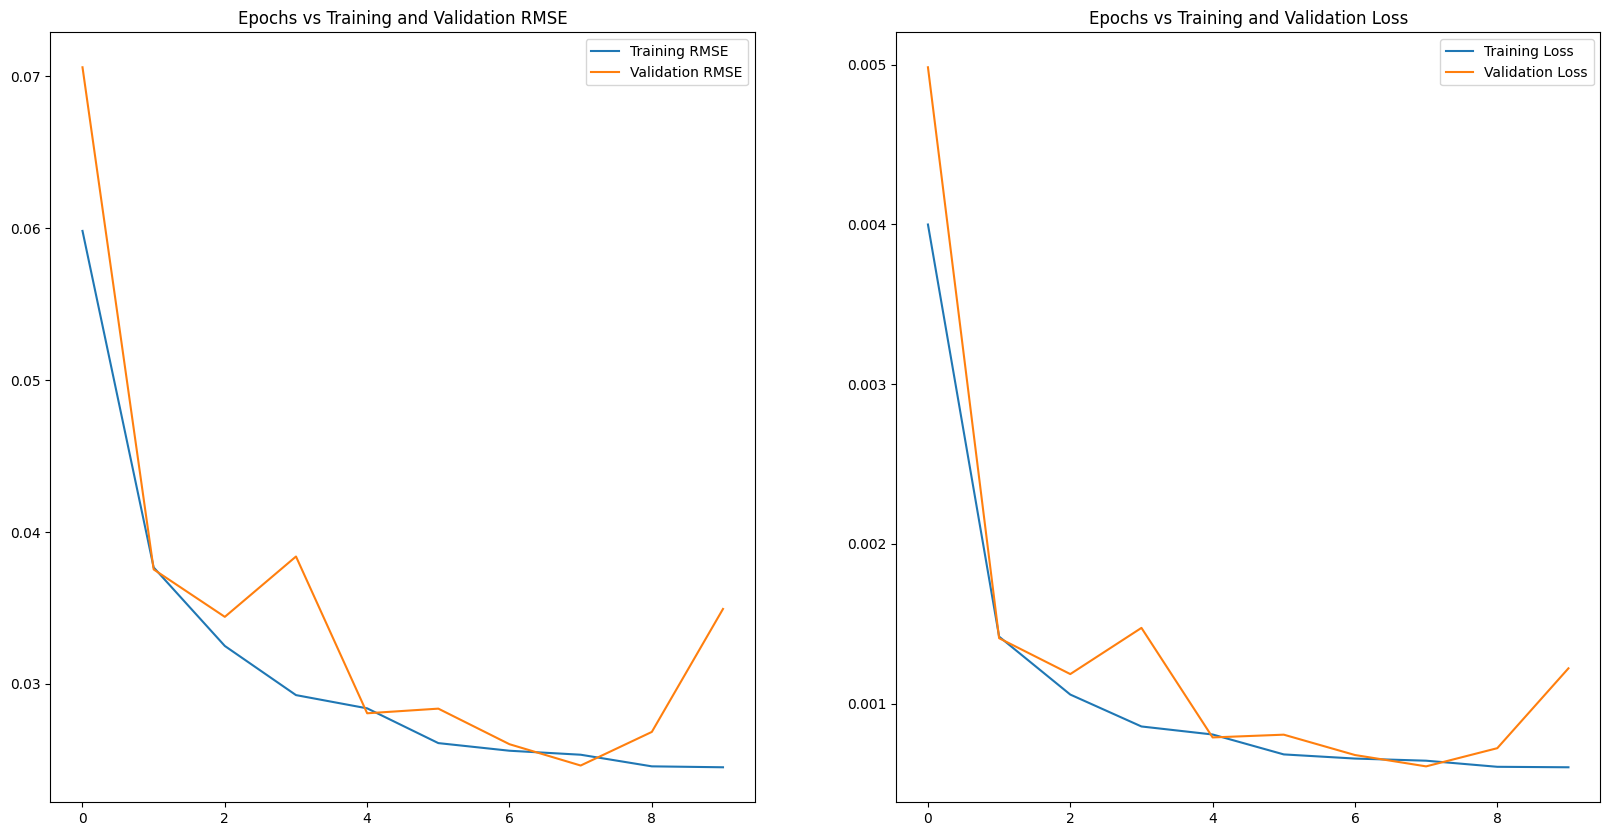

In [48]:
plot_model_rmse_and_loss(history)

In [50]:
encoder_decoder = tf.keras.models.load_model('encoder_decoder.h5')

forecast = encoder_decoder.predict(X_test)
encoder_decoder_forecast = scaler_y.inverse_transform(forecast)

rmse_encoder_decoder = np.sqrt(mean_squared_error(y_test_inv, 
                                               encoder_decoder_forecast))
print('RMSE of hour-ahead electricity price Encoder-Decoder forecast: {}'
      .format(round(rmse_encoder_decoder, 3)))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
RMSE of hour-ahead electricity price Encoder-Decoder forecast: 2.488


In [32]:
print(type(multivariate_stacked_lstm_forecast))
print(multivariate_stacked_lstm_forecast.shape)

<class 'numpy.ndarray'>
(3984, 1)


In [33]:
# Create forecast df with lowest rmse model 
forecast_prices = multivariate_stacked_lstm_forecast.ravel()
actual_prices = y_test_inv.ravel()

test_timestamps = df_final.index[
    cv_end_idx + past_history:test_end_idx
]

results_df = pd.DataFrame(
    {
        'forecast_price': forecast_prices,
        'actual_price': actual_prices
    },
    index=test_timestamps
)

results_df.index.name = 'time'

In [34]:
print(results_df.head())
print(results_df.tail())
print(results_df.shape)

print("Forecasts:", len(forecast_prices))
print("Actual prices:", len(actual_prices))
print("Timestamps:", len(test_timestamps))

                           forecast_price  actual_price
time                                                   
2018-07-18 23:00:00+00:00       64.350502         67.08
2018-07-19 00:00:00+00:00       64.309013         65.19
2018-07-19 01:00:00+00:00       65.384933         62.87
2018-07-19 02:00:00+00:00       60.912739         63.02
2018-07-19 03:00:00+00:00       63.610653         64.50
                           forecast_price  actual_price
time                                                   
2018-12-31 18:00:00+00:00       80.200623         77.02
2018-12-31 19:00:00+00:00       77.952477         76.16
2018-12-31 20:00:00+00:00       76.531738         74.30
2018-12-31 21:00:00+00:00       73.440613         69.89
2018-12-31 22:00:00+00:00       70.857834         69.88
(3984, 2)
Forecasts: 3984
Actual prices: 3984
Timestamps: 3984


In [36]:
results_df.to_csv('../data/results_df.csv', index=True)